# Avaliação - Parte Prática

Na parte prática da avaliação, você vai trabalhar com um projeto de uma aplicação com redes neurais de ponta a ponta. O objetivo é obter um modelo para classificação de tipos de arritmias cardíacas usando sinais de eletrocardiograma (ECG) como entrada. Neste projeto, você vai trabalhar não só com a proposta da arquitetura do modelo para classificação mas também com a preparação dos dados, necessária em qualquer aplicação prática de aprendizado de máquinas.

## Sinal de ECG

O sinal de ECG registra a atividade elétrica do coração, por meio de eletrodos que são colocados nos membros ou no tórax do paciente. De forma simplificada, o sinal referente a um batimento cardíaco tem a seguinte forma:

![ECG](images/ecg_beat.png)

Como mostrado na figura, o sinal referente a um batimento cardíaco tem formas de onda características, identificadas pelos pontos P, Q, R, S e T e tem alguns intervalos e segmentos que são utilizados por especialistas para fazer o diagnóstico de doenças cardíacas. Além disso, em geral, em um exame de ECG são registrados vários sinais chamados de *derivações* que representam a diferença de potencial entre diferentes pares ou combinações de eletrodos. Neste projeto, você vai trabalhar com uma única derivação do sinal de ECG e não é necessário um entendimento em detalhes sobre a morfologia dos sinais. No entanto, caso queira se aprofundar, uma boa referência é o artigo [Geselowitz - On the theory of the electrocardiogram, 1989](https://ieeexplore.ieee.org/document/29327)

## Dados disponibilizados

Para os fins do projeto, considere apenas que um sinal é uma série temporal, composta por amostras de vários batimentos cardíacos sequenciais e que cada batimento cardíaco tem uma classificação que pode ser normal ou com algum tipo de arritimia. Você vai trabalhar com o sinais contidos no [banco de dados de arritimia do MIT](https://physionet.org/content/mitdb/1.0.0/) mas, para facilitar o trabalho de carregamento dos sinais, estamos disponibilizando os <a href="./assets/datasets/ecg/dados_ecg.zip">dados no formato CSV </a>no repositório de materiais.

Dentro do arquivo compactado, são disponibilizados os seguintes arquivos para treinamento do modelo:
- `ecg_treino.csv`: amostras dos sinais de ECG para treinamento do modelo
- `rotulos_treino.csv`: rótulos para cada batimento cardíaco, representando a classificação normal (N) ou com algum tipo de arritmia (F, Q, S ou V)
- `n_rotulos_treino.csv`: cada rótulo é localizado sobre o ponto R de um batimento cardíaco (note na forma de onda que o ponto R é onde geralmente ocorre o pico do sinal) e neste arquivo são armazenados os índices onde se localizam os pontos R dos batimentos

E os seguintes arquivos para teste, com conteúdo análogo:
- `ecg_teste.csv`
- `rotulos_teste.csv`
- `n_rotulos_teste.csv`

In [1]:
!cp ./assets/datasets/ecg/*.csv ./

Para entender melhor a estrutura dos arquivos, vamos analisar alguns batimentos. Para carregar os arquivos CSV, você pode utilizar a biblioteca Pandas:

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ecg_treino = pd.read_csv("ecg_treino.csv")
rotulos_treino = pd.read_csv("rotulos_treino.csv")
n_rotulos_treino = pd.read_csv("n_rotulos_treino.csv")  

O DataFrame com as amostras dos sinais tem a seguinte estrutura:

In [3]:
ecg_treino.head()

,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,649990,649991,649992,649993,649994,649995,649996,649997,649998,649999
0,Paciente101,-0.345,-0.345,-0.345,-0.345,-0.345,-0.345,-0.345,-0.345,-0.330,...,-0.300,-0.295,-0.285,-0.280,-0.285,-0.290,-0.295,-0.295,-0.290,0.00
1,Paciente106,-0.310,-0.310,-0.310,-0.310,-0.310,-0.310,-0.310,-0.310,-0.290,...,1.970,1.900,1.785,1.690,1.550,1.355,1.040,0.635,0.265,0.00
2,Paciente108,-0.125,-0.125,-0.125,-0.125,-0.125,-0.125,-0.125,-0.125,-0.135,...,-0.135,-0.110,-0.095,-0.110,-0.155,-0.165,-0.095,-0.010,0.040,0.00
3,Paciente109,0.175,0.175,0.175,0.175,0.175,0.175,0.175,0.175,0.175,...,-0.885,-0.885,-0.885,-0.875,-0.900,-0.900,-0.910,-0.920,-0.910,-1.28
4,Paciente112,-0.750,-0.750,-0.750,-0.750,-0.750,-0.750,-0.750,-0.760,-0.770,...,-0.940,-0.925,-0.915,-0.890,-0.885,-0.845,-0.820,-0.825,-0.810,-1.28


In [4]:
ecg_treino.shape

(22, 650001)

Note que cada linha corresponde às amostras do sinal de ECG de um paciente diferente, identificado pela coluna `Unnamed: 0`. Além disso, ao todo são armazenados dados de 22 pacientes no arquivo `ecg_treino.csv`. Segue um gráfico com as primeiras 600 amostras do sinal de ECG do paciente identificado como `Paciente101`:

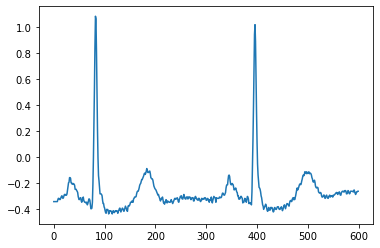

In [5]:
plt.plot(ecg_treino.iloc[0].drop('Unnamed: 0').to_numpy()[:600])

Note que nesse trecho podemos identificar dois batimentos cardíacos. Os índices referentes aos pontos R de cada batimento cardíaco dos sinais foram carregados no DataFrame `n_rotulos_treino`:

In [6]:
n_rotulos_treino.head()

,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,3353,3354,3355,3356,3357,3358,3359,3360,3361,3362
0,Paciente101,83,396,711,1032,1368,1712,2036,2349,2662,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Paciente106,351,724,1086,1448,1829,2197,2571,2918,3234,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Paciente108,88,442,789,1155,1493,1821,2157,2517,2889,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Paciente109,111,343,571,807,1048,1287,1523,1765,1994,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Paciente112,124,382,644,892,1149,1393,1648,1891,2147,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Para o paciente identificado como `Paciente101`, note que os pontos R dos dois primeiros batimentos estão situados nos índices 83 e 396, conforme mostrado na figura abaixo:

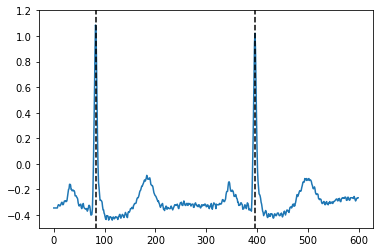

In [7]:
plt.figure()
ax = plt.subplot(1,1,1)
plt.plot(ecg_treino.iloc[0].drop('Unnamed: 0').to_numpy()[:600]);
plt.plot([83, 83], [-0.8, 1.5], 'k--');
plt.plot([396, 396], [-0.8, 1.5], 'k--');
ax.set(ylim=(-0.5, 1.2));

Cada batimento é rotulado com a classificação normal (N) ou com algum tipo de arritmia (F, Q, S ou V) e os rótulos foram carregados no DataFrame `rotulos_treino`:

In [8]:
rotulos_treino.head()

,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,3353,3354,3355,3356,3357,3358,3359,3360,3361,3362
0,Paciente101,N,N,N,N,N,N,N,N,N,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Paciente106,N,N,N,N,N,N,N,N,N,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Paciente108,N,N,N,N,N,N,N,N,N,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Paciente109,N,N,N,N,N,N,N,N,N,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Paciente112,N,N,N,N,N,N,N,N,N,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Nesse caso, os dois primeiros batimentos para o paciente identificado como `Paciente101` são to tipo normais (N).

Note que os DataFrames `n_rotulos_treino` e `rotulos_treino` possuem diversos valores `NaN` nas últimas colunas. Isso acontece pois, apesar dos sinais de ECG dos diversos pacientes terem o mesmo número de amostras, o número de batimentos cardíacos em cada um é diferente, já que o ritmo cardíaco é diferente entre os pacientes. Nesse banco de dados de treinamento, o sinal com maior número de batimentos cardíacos contém 3362, que é igual ao número de colunas do DataFrame. Para os demais sinais, mais curtos, o excedente de colunas do DataFrame é preenchido com valores `NaN`.

In [9]:
rotulos_treino.drop(columns=['Unnamed: 0']).to_numpy()[:, -3:]

array([[nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       ['N', 'N', 'N'],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan]], dtype=object)

## Objetivo



O objetivo do projeto é obter um modelo que receba a informação de um batimento cardíaco e forneça a classificação de arritmia. Você deve trabalhar com dois modelos:
1) Classificador binário, com o objetivo de dizer se um batimento tem algum tipo de arritmia (1) ou é um batimento normal (0);
2) Classificador multiclasse, com o objetivo de classificar um batimento entre as classes N, S e V (desconsidere as demais classes, nesse caso).

A definição da entrada que será utilizada no modelo é parte do projeto e tem grande relevância no desempenho do classificador. Seguem algumas sugestões:
- A forma mais simples é considerar como entrada do modelo as amostras de um batimento cardíaco. No entanto, é necessário levar em conta que o comprimento de cada batimento cardíaco é diferente, variando com o ritmo cardíaco do paciente. Para contornar esse problema, uma ideia é calcular o comprimento médio dos batimentos e usar esse resultado para o número de amostras que serão utilizadas como entrada do modelo. O comprimento de cada batimento em termos do número de amostras pode ser medido como a diferença entre o índice de um pico R o índice do pico R seguinte. Para segmentação de um batimento cardíaco, pode-se considerar amostras em torno do pico R;
- O problema de arritimia está muito relacionado com a cadência entre os batimentos. Assim, informações adicionais como o valor em amostras do intervalo RR entre batimentos pode ajudar;
- Outra ideia que pode ajudar na classificação de arritmia é considerar mais de um batimento cardíaco na entrada da rede incluindo, de forma implícita, informação sobre a cadência dos batimentos. Nesse caso você pode, por exemplo, considerar as amostras de 3 batimentos cardíacos na entrada da rede para a classificação do batimento central;
- Também é comum encontrar abordagens que utilizam transformadas do sinal na entrada do modelo, usando a transformada de Fourier ou transformada wavelet, por exemplo.

Após a definição da entrada, projete o modelo, considerando as arquiteturas e as técnicas que foram vistas no curso. Note que este problema tem dados altamente desbalanceados, assim como ocorre na maioria dos problemas de detecção de anomalia. Nesse caso, a maioria dos batimentos cardíacos são do tipo normal (N) e há um número bem menor de exemplos que apresentam classificação de algum tipo de arritmia. Para contornar esse problema seguem algumas sugestões:
- Fazer sobreamostragem das classes menos representativas. Nesse caso, a ideia mais simples é aumentar o número de repetições dos exemplos no conjunto de treinamento. Entretanto, a simples repetição dos exemplos pode fazer com que o modelo sofra *overfitting* aos dados de treinamento. Para evitar esse problema, é comum utilizar técnicas de aumento de dados (*data augmentation*) como o [SMOTE](https://machinelearningmastery.com/smote-oversampling-for-imbalanced-classification/), que pode ser implementado com o auxílio da biblioteca [imbalanced-learn](https://github.com/scikit-learn-contrib/imbalanced-learn);
- Usar uma função custo ponderada por pesos inversamente proporcionais ao número de elementos das classes. Dessa forma, um erro de classificação para um exemplo com poucos elementos no conjunto de treinamento é mais penalizado que um erro para um elemento de uma classe mais frequente. No caso do PyTorch, os pesos para cada classe podem ser configurados por meio do argumento `weights` (veja, por exemplo, o caso da entropia cruzada com a função [nll_loss](https://pytorch.org/docs/stable/generated/torch.nn.functional.nll_loss.html)). Para o cálculo dos valores dos pesos, o scikit-learn oferece uma [função que implementa uma das abordagens mais utilizadas](https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_class_weight.html).

O modelo deve ser treinado com dados do conjunto de treinamento e, após o treinamento, testado fazendo inferência para o conjunto de teste. Note que os pacientes do conjunto de treinamento são diferentes dos pacientes do conjunto de teste, conforme esperado em uma aplicação prática.

Para implementação do modelo e treinamento da rede, você pode utilizar um framework de redes neurais, como PyTorch ou Keras.

No final do exercício, você deve apresentar para ambos os classificadores, binário e multiclasse:
1) Sua escolha para a entrada da rede e os motivos que o levaram a fazer essa escolha;
2) Sua escolha para a arquitetura do modelo e os motivos que o levaram a fazer essa escolha;
3) Os códigos utilizados para treinamento e teste;
4) A curva de aprendizado em termos da função custo ao longo das épocas e a matriz de confusão obtida com os dados de teste;
5) Métricas de desempenho no conjunto de teste que julgarem adequadas para o problema.

Algumas referências que podem ser úteis:

- P. de Chazal, M. O'Dwyer, and R. B. Reilly, "Automatic classification of heartbeats using ECG morphology and heartbeat interval features," IEEE Trans. Biomed. Eng., vol. 51, pp. 1196–1206, 2004

- T. Mar et al., "Optimization of ECG classification by means of feature selection", IEEE Trans. Biomed. Eng., vol. 58, pp. 2168–2177, 2011.

- M. Llamedo and J. P. Martínez, "Heartbeat classification using feature selection driven by database generalization criteria”, IEEE Trans. Biomed. Eng., vol. 58, pp. 616–625, 2011.

- C. Lin and C. Yang, "Heartbeat classification using normalized RR intervals and morphological features", Mathematical Problems in Engineering, 2014.

- G. Garcia et al., "Improving automatic cardiac arrhythmia classification: Joining temporal-VCG, complex networks and SVM classifier," in 2016 International Joint Conference on Neural Networks (IJCNN). IEEE, 2016, pp. 3896–3900.

- G. Garcia et al., "Inter-patient ECG heartbeat classification with temporal VCG optimized by PSO," Scientific Reports, vol. 7, pp. 1–11, 2017.